[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1s8oBKg3jAWIC3BgkJyOX3q3rWruB5MBQ)

https://en.wikipedia.org/wiki/K-means_clustering

### Pseudo-Code:

1. Pick a random starting point c_k for k clusters
2. For each point, add it to the set $S_k$ of the centroid $c_k$ it is closest to
3. Recompute each $c_k$ as the mean (centroid) of each set $S_k$
4. Do until $c_k$ doesn't change for any $k$ (or max iter is hit)

In [0]:
max_iterations = 50
k = 3

In [0]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns; sns.set()

/usr/local/lib/python3.6/dist-packages/matplotlib/cbook/deprecation.py:106: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  warnings.warn(message, mplDeprecation, stacklevel=1)


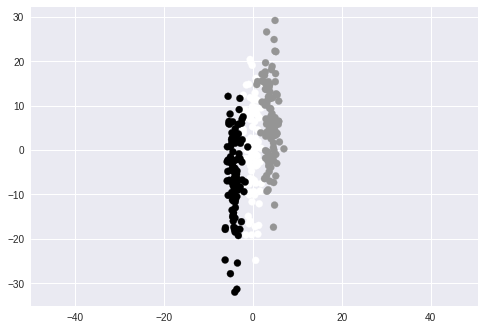

In [24]:
TOTAL_NUMBER_OF_POINTS = 100

points = np.vstack(((np.random.multivariate_normal([0, 0], [[1, 0], [0, 100]] , TOTAL_NUMBER_OF_POINTS)),
                  (np.random.multivariate_normal([4, 4], [[1, 0], [0, 100]] , TOTAL_NUMBER_OF_POINTS)),
                  (np.random.multivariate_normal([-4, -4], [[1, 0], [0, 100]] , TOTAL_NUMBER_OF_POINTS))))

true_class_colors = np.hstack((np.ones(TOTAL_NUMBER_OF_POINTS),
                               np.ones(TOTAL_NUMBER_OF_POINTS)*2,
                               np.ones(TOTAL_NUMBER_OF_POINTS)*3))

plt.scatter(points[:, 0], points[:, 1], c=true_class_colors)
plt.axes().set_aspect('equal', 'datalim');

### Choose k random points from the set to be our starting "centroids"

In [0]:
def get_random_centroids(points, number):
  return points[np.random.permutation(len(points))[0:number]]

In [40]:
centroids = get_random_centroids(points, k)
centroids

array([[ -5.06209129, -27.85078812],
       [ -2.92938095,  11.60658875],
       [ -6.25488393, -24.76269008]])

### Let's plot our starting centroids

/usr/local/lib/python3.6/dist-packages/matplotlib/cbook/deprecation.py:106: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  warnings.warn(message, mplDeprecation, stacklevel=1)


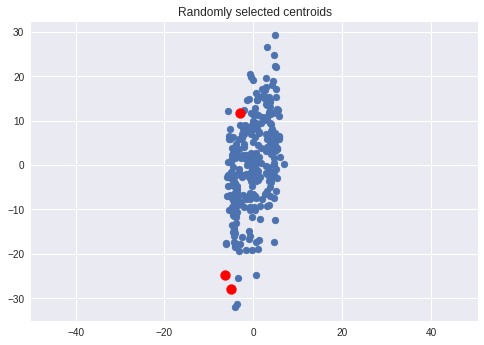

In [41]:
plt.scatter(points[:, 0], points[:, 1])
plt.title('Randomly selected centroids')
plt.scatter(centroids[:, 0], centroids[:, 1], c='r', s=100)
plt.axes().set_aspect('equal', 'datalim');

### Calculate closest centroid

In [0]:
def dist(a, b, ax=1):
  return np.linalg.norm(a - b, axis=ax)

In [0]:
def closest_centroid_for_all_points(points, centroids):
  clusters = np.zeros(len(points))
  for i in range(len(points)):
      distances = dist(points[i], centroids)
      clusters[i] = np.argmin(distances)
  return clusters

In [44]:
closest = closest_centroid_for_all_points(points, centroids)
closest

array([1., 2., 2., 2., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2.,
       1., 1., 1., 2., 1., 1., 1., 2., 1., 1., 1., 1., 1., 2., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 2., 1.,
       1., 2., 1., 1., 0., 1., 1., 1., 2., 1., 1., 1., 1., 2., 1., 2., 1.,
       1., 1., 2., 2., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 2.,
       1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 2., 2., 1., 1., 2., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 2., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2.,
       2., 0., 1., 2., 2., 1., 1., 1., 1., 1., 2., 2., 1., 1., 2., 1., 2.,
       1., 2., 2., 1., 1.

Let's plot how do our clusters look at initial configuration

/usr/local/lib/python3.6/dist-packages/matplotlib/cbook/deprecation.py:106: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  warnings.warn(message, mplDeprecation, stacklevel=1)


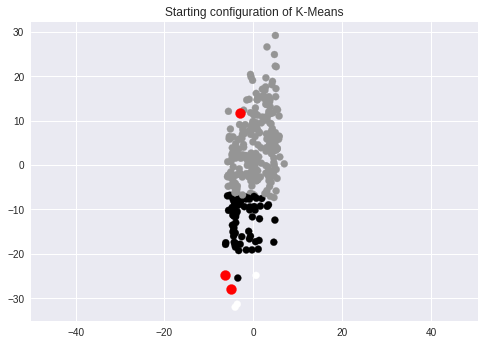

In [45]:
plt.scatter(points[:, 0], points[:, 1], c=(closest+1))
plt.scatter(centroids[:, 0], centroids[:, 1], c='r', s=100)
plt.axes().set_aspect('equal', 'datalim')
plt.title('Starting configuration of K-Means');

### Re-calculate the centroids for each cluster based on the points that were added to it

In [0]:
def recalculate_centroids(points, closest, centroids):
  for k in range(centroids.shape[0]):
      cluster = points[closest==k]
      centroids[k] = cluster.mean(axis=0)
  return centroids

In [47]:
new_centroids = recalculate_centroids(points, closest, centroids)
new_centroids

array([[ -3.03277108, -29.01353329],
       [  0.63690111,   4.68237966],
       [ -2.30655447, -12.57788587]])

/usr/local/lib/python3.6/dist-packages/matplotlib/cbook/deprecation.py:106: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  warnings.warn(message, mplDeprecation, stacklevel=1)


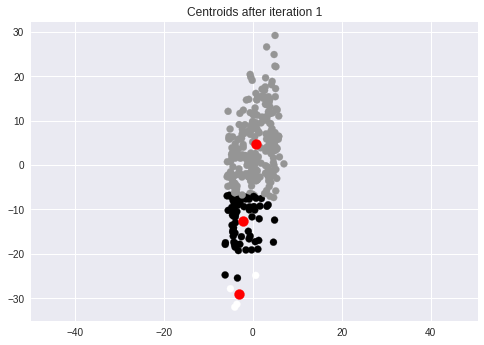

In [48]:
plt.scatter(points[:, 0], points[:, 1], c=(closest+1))
plt.scatter(new_centroids[:, 0], new_centroids[:, 1], c='r', s=100)
plt.axes().set_aspect('equal', 'datalim')
plt.title('Centroids after iteration 1');

### Iterate

/usr/local/lib/python3.6/dist-packages/matplotlib/cbook/deprecation.py:106: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  warnings.warn(message, mplDeprecation, stacklevel=1)


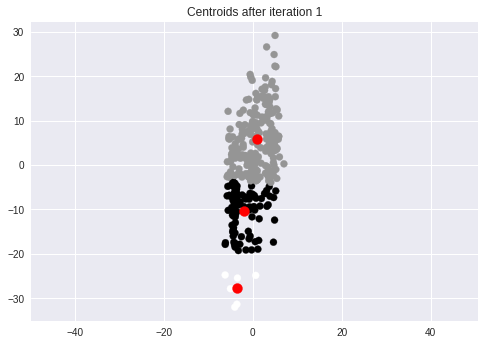

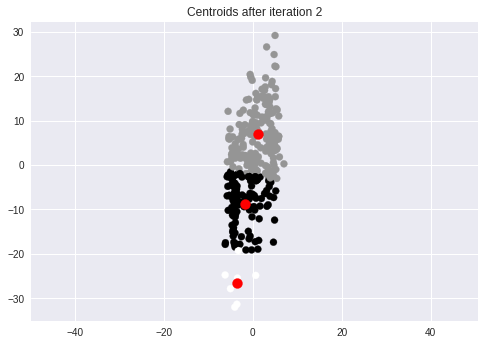

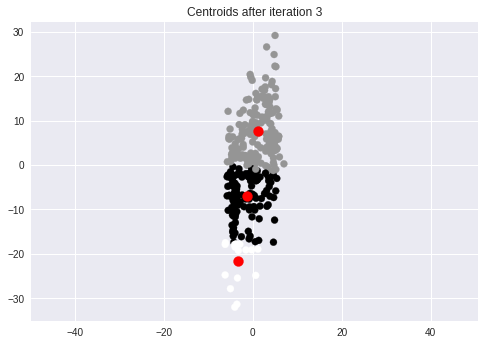

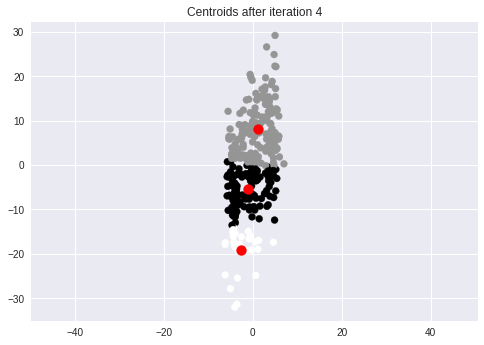

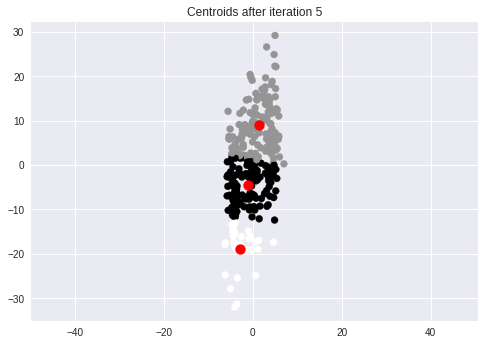

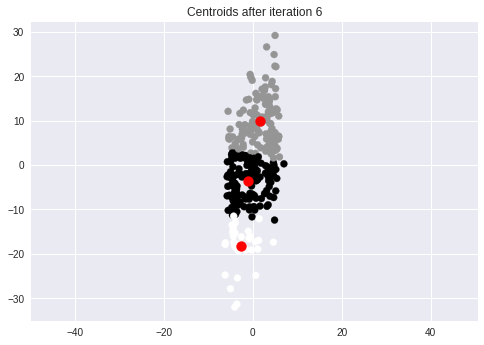

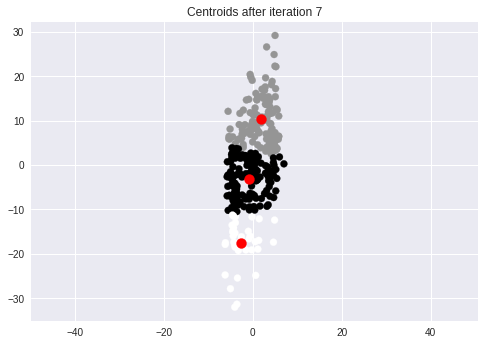

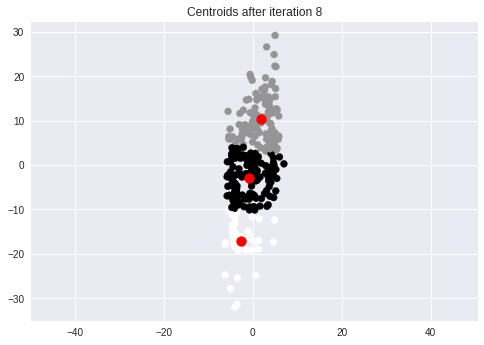

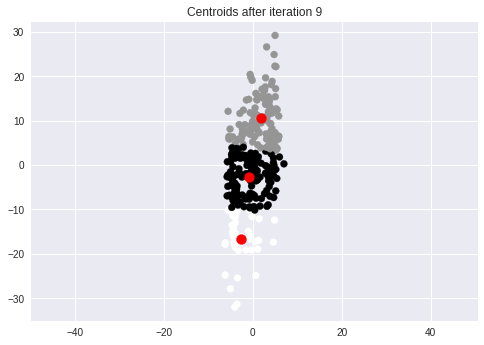

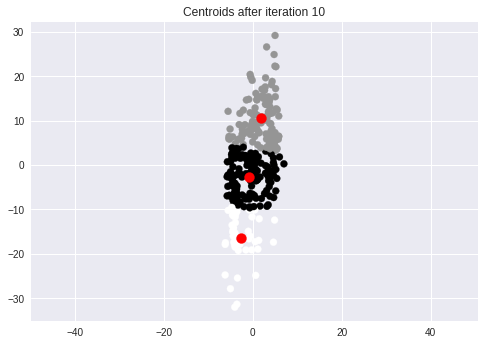

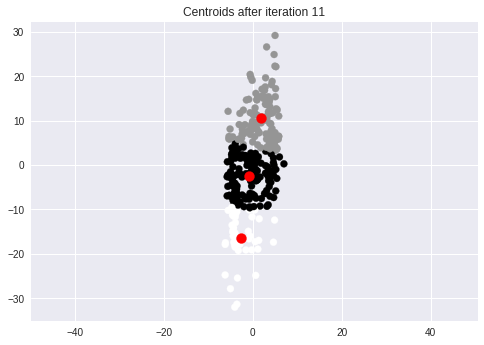

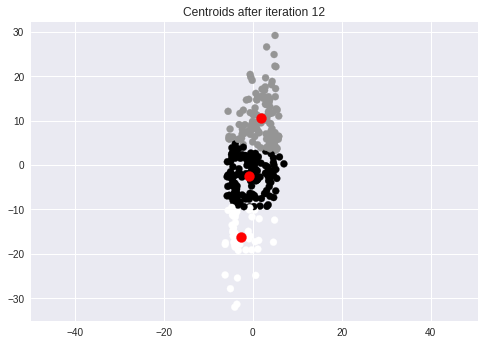

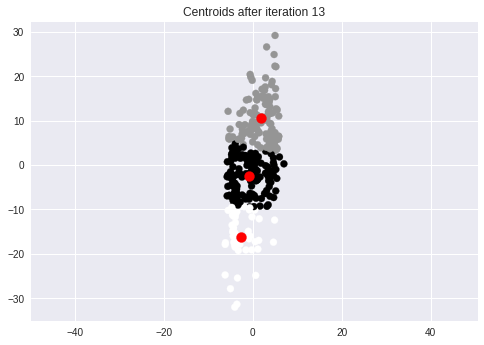

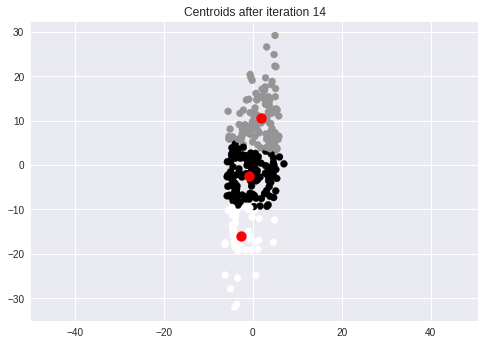

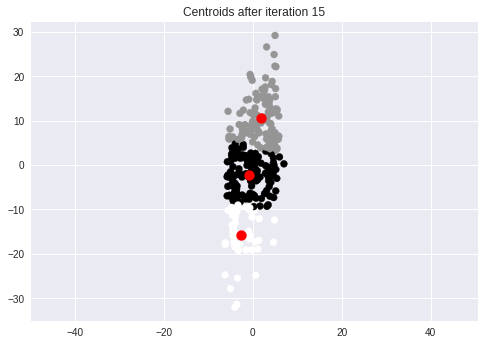

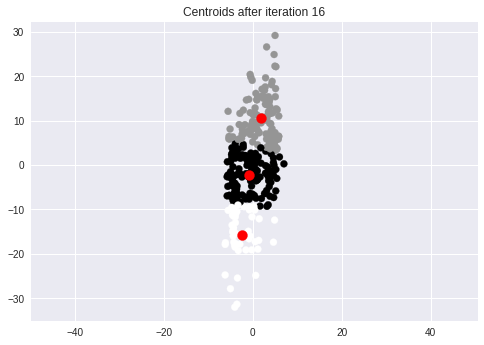

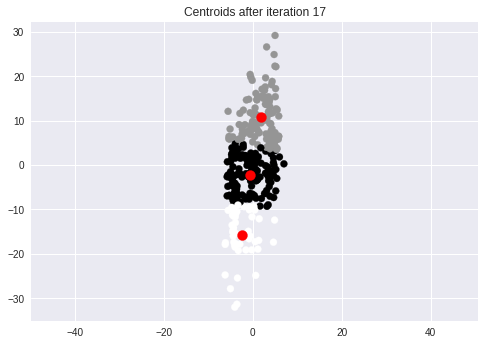

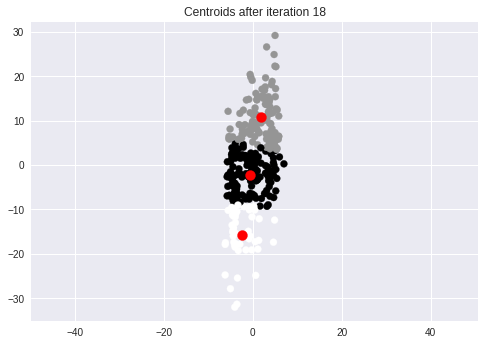


Clusters converged in 18 iterations


In [49]:
last_closest = []
for i in range(max_iterations):
  closest = closest_centroid_for_all_points(points, centroids)
  centroids = recalculate_centroids(points, closest, centroids)
  plt.axes().set_aspect('equal', 'datalim')
  plt.scatter(points[:, 0], points[:, 1], c=(closest+1))
  plt.scatter(new_centroids[:, 0], new_centroids[:, 1], c='r', s=100)
  plt.axes().set_aspect('equal', 'datalim')
  plt.title('Centroids after iteration %d' % (i+1))
  plt.show();
  if np.array_equal(last_closest,closest):
    print()
    print('Clusters converged in %d iterations' % (i+1))
    break
  last_closest = closest